# Clustering Using Spherical K-means

Notebook ini menjalankan clustering bertingkat berbasis spherical k-means terhadap embedding tiket, lalu menyimpan hasil eksperimen, label cluster, visualisasi, dan data representatif.

## Set up Environment

Bagian ini menyiapkan lingkungan kerja untuk proses clustering dan visualisasi, termasuk pustaka numerik, plotting, dan FAISS.

### Install Dependencies

Sel ini memasang paket yang dibutuhkan untuk komputasi numerik, clustering, visualisasi, dan evaluasi hasil cluster.

In [1]:
%pip install --upgrade numpy pandas matplotlib wordcloud scikit-learn tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install --upgrade faiss-cpu

   ---------------------------------------- 0.0/16.3 MB ? eta -:--:--
   --- ------------------------------------ 1.6/16.3 MB 10.5 MB/s eta 0:00:02
   --------- ------------------------------ 3.7/16.3 MB 9.5 MB/s eta 0:00:02
   ------------- -------------------------- 5.5/16.3 MB 9.1 MB/s eta 0:00:02
   ------------------ --------------------- 7.3/16.3 MB 9.1 MB/s eta 0:00:01
   ----------------------- ---------------- 9.4/16.3 MB 9.0 MB/s eta 0:00:01
   --------------------------- ------------ 11.3/16.3 MB 9.2 MB/s eta 0:00:01
   -------------------------------- ------- 13.4/16.3 MB 9.2 MB/s eta 0:00:01
   ------------------------------------- -- 15.2/16.3 MB 9.1 MB/s eta 0:00:01
   ---------------------------------------- 16.3/16.3 MB 9.1 MB/s  0:00:01
  Attempting uninstall: faiss-cpu
    Found existing installation: faiss-cpu 1.14.3
    Uninstalling faiss-cpu-1.14.3:
      Successfully uninstalled faiss-cpu-1.14.3
Note: you may need to restart the kernel to use updated packages.


### Import Dependencies

Semua modul yang dipakai selama eksperimen dimuat di sini, mulai dari FAISS, pandas, numpy, sampai utilitas visualisasi.

In [3]:
import math
import os
import re
import faiss
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from wordcloud import WordCloud
from sklearn.metrics import silhouette_score
from tqdm import tqdm
from sklearn.manifold import TSNE

### Load Data

Data hasil preprocessing dan embedding dimuat kembali sebagai input utama eksperimen clustering.

In [4]:
df = pd.read_pickle('datasets/tickets.pkl')

X_embeddings = np.vstack(df['EMBEDDING'].values)
embedding_dimension = X_embeddings.shape[1]

print("Vektor embedding berhasil dimuat kembali.")
print(f"Jumlah data: {X_embeddings.shape[0]}")
print(f"Dimensi embedding: {embedding_dimension}")

df.head()

Vektor embedding berhasil dimuat kembali.
Jumlah data: 1639
Dimensi embedding: 256


,RAW TICKET,CLEANED TICKET,NORMALIZED TICKET,EMBEDDING,WORDCLOUD TICKET
0,Klien: Setwapres Medsos\nisu: Crawlback Commen...,Crawlback Comment. Siang tim IT minta tolong b...,crawlback comment. sapaan tim it sapaan bantua...,"[0.00083771703, -0.58585614, 0.064690515, 0.08...",crawlback comment. bantuan crawlback comment m...
1,"selamat pagi tim it, mohon bantuannya saya men...","selamat pagi tim it, mohon bantuannya saya men...","sapaan tim it, sapaan saya menemukan link dari...","[0.02750907, 0.037827827, -0.5283966, -0.13133...",menemukan megapolitan.kompas.com tidak masuk d...
2,Klien: BPS\nIsu: Data postingan Instagram tida...,Data postingan Instagram tidak masuk. Selamat ...,data postingan instagram tidak masuk. sapaan t...,"[-0.17697816, -0.045605347, -0.3471804, 0.4249...",postingan instagram tidak masuk. apa bikin pos...
3,selamat sore mas @Dhanysybn dan tim info untuk...,selamat sore mas @Dhanysybn dan tim info untuk...,sapaan mas nama orang dan tim info untuk siput...,"[0.08603829, -0.017807081, 0.016980363, 0.3204...",siputri tidak bisa akses minta yaaa.
4,Klien: Heinz \nIsu: Dashboard loading\n\nSelam...,"Dashboard loading. Selamat sore tim IT, mohon ...","dashboard loading. sapaan tim it, sapaan ada k...","[0.14301413, 0.028007613, 0.030197145, 0.24381...",dashboard loading. keluhan pihak heinz dashboa...


## Experimenting

Bagian inti notebook ini menjalankan eksperimen clustering bertingkat untuk berbagai kombinasi jumlah cluster dan menyimpan seluruh hasil evaluasi.

### Normalize Data

Embedding dinormalisasi agar cocok dengan spherical k-means dan evaluasi berbasis cosine similarity.

In [5]:
X_embeddings = np.ascontiguousarray(X_embeddings, dtype=np.float32)
faiss.normalize_L2(X_embeddings)

print("Vektor embedding berhasil dinormalisasi.")

Vektor embedding berhasil dinormalisasi.


### Initialize Spherical K-means

Fungsi ini menjalankan spherical k-means menggunakan FAISS dan mengembalikan centroid beserta label cluster.

In [6]:
def run_skm(dimension, ncluster, X, niter=20):
    skm = faiss.Kmeans(
        d=dimension, 
        k=ncluster, 
        niter=niter, 
        verbose=True, 
        spherical=True
        )
    skm.train(X)

    centroids = skm.centroids
    _, labels = skm.index.search(X, 1)

    return centroids, labels.flatten()

In [7]:
def generate_wordclouds(texts_list, titles, save_path, main_title="", top_n=5):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    
    n_clouds = len(texts_list)
    top_words_per_cluster = []  # hasil yang dikembalikan
    
    if n_clouds == 0:
        return top_words_per_cluster
        
    cols = min(3, n_clouds)
    rows = math.ceil(n_clouds / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4.5))
    if main_title:
        fig.suptitle(main_title, fontsize=20, y=1.02)
        
    if n_clouds == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
        
    for i in range(len(axes)):
        if i < n_clouds:
            combined_text = texts_list[i]
            if combined_text.strip():
                wc = WordCloud(
                    width=800, height=400,
                    background_color='white',
                    max_words=100,
                    collocations=False
                ).generate(combined_text)
                
                # Ekstrak top words dari objek wc yang sudah terbentuk
                word_freq = wc.process_text(combined_text)  # {kata: count_absolut}
                total = sum(word_freq.values())
                top_n_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:top_n]
                top_words_per_cluster.append(
                    "; ".join(f"({word}, {count/total*100:.2f}%)" for word, count in top_n_words)
                )
                
                axes[i].imshow(wc, interpolation='bilinear')
            else:
                top_words_per_cluster.append("")
                axes[i].text(0.5, 0.5, 'Tidak ada teks', ha='center', va='center', fontsize=14)
                
            axes[i].set_title(titles[i], fontsize=16, pad=10)
            axes[i].axis('off')
        else:
            axes[i].axis('off')
            
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.close(fig)
    
    return top_words_per_cluster  # list, panjang = n_clouds

In [8]:
def cosine_similarity_intra_cluster(embeddings, labels, centroids):
    centroids_norm = centroids / np.linalg.norm(centroids, axis=1, keepdims=True)
    sims = np.sum(embeddings * centroids_norm[labels], axis=1)
    return float(np.mean(sims))

### Run Experiments Scenario

Sel ini menguji berbagai skenario k1 dan k2, membuat word cloud, menghitung metrik evaluasi, dan menyimpan label tiap level cluster.

In [9]:
min_clusters = 2
max_clusters = 10
k_range = range(min_clusters, max_clusters + 1)

results = []
scenario_count = 0
wordcloud_texts = df['WORDCLOUD TICKET'].astype(str).values

total_iterations = sum(k1 * len(k_range) for k1 in k_range)

with tqdm(total=total_iterations, desc="Evaluasi + WordCloud") as pbar:
    
    for k1 in k_range:
        centroids_l1, labels_l1 = run_skm(embedding_dimension, k1, X_embeddings)
        silhouette_avg_l1 = silhouette_score(X_embeddings, labels_l1, metric='cosine')

        # Hitung n_output dan n_clustered untuk Level 1
        n_output_l1 = len(X_embeddings)
        n_clustered_l1 = np.sum(labels_l1 >= 0)

        # --- WordCloud Level 1 Gabungan ---
        l1_texts_list = []
        l1_titles = []
        cluster_texts_dict = {}
        
        for cluster_id in range(k1):
            cluster_indices = np.where(labels_l1 == cluster_id)[0]
            cluster_texts = wordcloud_texts[cluster_indices].tolist()
            cluster_texts_dict[cluster_id] = (cluster_embeddings:=X_embeddings[cluster_indices], cluster_texts, cluster_indices)
            
            l1_texts_list.append(" ".join(cluster_texts))
            l1_titles.append(f"Cluster L1 - {cluster_id + 1}")
            
        top_words_list_l1 = generate_wordclouds(
            l1_texts_list,
            l1_titles,
            f"results/wordclouds/k{k1}/L1_combined.png",
            main_title=f"Level 1 Wordclouds (k={k1})",
            top_n=3
        )

        # simpan label cluster L1
        labels_df_l1 = pd.DataFrame({
            'ticket': df['RAW TICKET'],
            'cluster_id': labels_l1 + 1  # 1-indexed
        })
        labels_dir_l1 = f"results/labels/k{k1}"
        os.makedirs(labels_dir_l1, exist_ok=True)
        labels_df_l1.to_csv(
            f"{labels_dir_l1}/labels.csv",
            index=False,
            encoding='utf-8',
            quoting=csv.QUOTE_ALL
        )

        for cluster_id in range(k1):
            cluster_embeddings, cluster_texts, cluster_indices = cluster_texts_dict[cluster_id]

            top_words_l1 = top_words_list_l1[cluster_id]

            for k2 in k_range:
                if len(cluster_embeddings) >= k2:
                    centroids_l2, labels_l2 = run_skm(embedding_dimension, k2, cluster_embeddings)
                    silhouette_avg_l2 = silhouette_score(cluster_embeddings, labels_l2, metric='cosine')

                    # Hitung n_output dan n_clustered untuk Level 2
                    n_output_l2 = len(cluster_embeddings)
                    n_clustered_l2 = np.sum(labels_l2 >= 0)

                    # --- WordCloud Level 2 Gabungan ---
                    l2_texts_list = []
                    l2_titles = []
                    
                    for sub_id in range(k2):
                        sub_indices = np.where(labels_l2 == sub_id)[0]
                        sub_texts = [cluster_texts[i] for i in sub_indices]

                        l2_texts_list.append(" ".join(sub_texts))
                        l2_titles.append(f"Sub-cluster L2 - {sub_id + 1}")

                    top_words_list_l2 = generate_wordclouds(
                        l2_texts_list,
                        l2_titles,
                        f"results/wordclouds/k{k1}/cluster_{cluster_id+1}_k{k2}/L2_combined.png",
                        main_title=f"Level 2: k={k2} (Berasal dari L1 Cluster {cluster_id + 1})",
                        top_n=3
                    )
                    # Susun format per sub-cluster
                    top_words_l2 = "; ".join(
                        f"(sub-cluster id, {sub_id + 1}; [{top_words_list_l2[sub_id]}])"
                        for sub_id in range(k2)
                    )

                    # --- Simpan Pemetaan Ticket -> Cluster (k1) & Sub-cluster (k2) ---
                    sub_cluster_ids = labels_l2 + 1  # 1-indexed agar konsisten dgn cluster_id

                    labels_df = pd.DataFrame({
                        'ticket': [df['RAW TICKET'].iloc[idx] for idx in cluster_indices],
                        'cluster_id': cluster_id + 1,
                        'sub_cluster_id': sub_cluster_ids
                    })

                    labels_dir = f"results/labels/k{k1}/cluster_{cluster_id+1}_k{k2}"
                    os.makedirs(labels_dir, exist_ok=True)
                    labels_df.to_csv(
                        f"{labels_dir}/labels.csv",
                        index=False,
                        encoding='utf-8',
                        quoting=csv.QUOTE_ALL
                    )

                    # --- Ending Conditions Check ---

                    # Objective Condition 1: semua input di L1 dan L2 berhasil diklastering
                    objective_condition_1 = "YES" if (n_clustered_l1 == n_output_l1 and n_clustered_l2 == n_output_l2) else "NO"

                    # Subjective Concise: k1 dan k2 berada dalam rentang [2, 10]
                    subjective_concise = "YES" if (2 <= k1 <= 10 and 2 <= k2 <= 10) else "NO"

                    # Subjective Robust: silhouette avg dalam [0, 0.5] DAN cosine similarity intra-cluster mendekati 1
                    cosine_sim_intra_l1 = cosine_similarity_intra_cluster(X_embeddings, labels_l1, centroids_l1)
                    cosine_sim_intra_l2 = cosine_similarity_intra_cluster(cluster_embeddings, labels_l2, centroids_l2)
                    COSINE_SIM_THRESHOLD = 0.75
                    is_silhouette_in_range = (0 <= silhouette_avg_l1 <= 0.5) and (0 <= silhouette_avg_l2 <= 0.5)
                    is_cosine_near_one = (cosine_sim_intra_l1 >= COSINE_SIM_THRESHOLD) and (cosine_sim_intra_l2 >= COSINE_SIM_THRESHOLD)
                    subjective_robust = "YES" if (is_silhouette_in_range and is_cosine_near_one) else "NO"

                    # Subjective Comprehensive: semua input di L1 dan L2 berhasil diklastering
                    subjective_comprehensive = "YES" if (n_clustered_l1 == n_output_l1 and n_clustered_l2 == n_output_l2) else "NO"

                    results.append({
                        'scenario_id': f"{k1-1}.{cluster_id+1}.{k2-1}",
                        'cluster_id': f"{k1}.{cluster_id+1}",
                        'k1': k1,
                        'k2': k2,
                        'silhouette_avg_l1': f"{silhouette_avg_l1:.4f}",
                        'silhouette_avg_l2': f"{silhouette_avg_l2:.4f}",
                        'cosine_sim_intra_l1': f"{cosine_sim_intra_l1:.4f}",
                        'cosine_sim_intra_l2': f"{cosine_sim_intra_l2:.4f}",
                        'n_output_l1': n_output_l1,
                        'n_clustered_l1': n_clustered_l1,
                        'n_output_l2': n_output_l2,
                        'n_clustered_l2': n_clustered_l2,
                        'objective_condition_1': objective_condition_1,
                        'subjective_concise': subjective_concise,
                        'subjective_robust': subjective_robust,
                        'subjective_comprehensive': subjective_comprehensive,
                        'top_words_l1': top_words_l1,
                        'top_words_l2': top_words_l2
                    })
                    scenario_count += 1
                
                pbar.update(1)

print(f"\nTotal scenario yang berhasil dievaluasi: {scenario_count}")
print("Semua gambar WordCloud telah digabung dan disimpan di results/wordclouds/")

Evaluasi + WordCloud: 100%|██████████| 486/486 [25:30<00:00,  3.15s/it]


Total scenario yang berhasil dievaluasi: 486
Semua gambar WordCloud telah digabung dan disimpan di results/wordclouds/


In [10]:
# ===== Ending Condition: Subjective Extendible =====
# Terpenuhi jika silhouette_avg_l1 adalah BEST untuk tingkat 1 tersebut
# DAN silhouette_avg_l2 adalah BEST di antara semua k2 untuk cluster_id (L1) yang sama.

results_df_temp = pd.DataFrame(results)
results_df_temp['silhouette_avg_l1'] = results_df_temp['silhouette_avg_l1'].astype(float)
results_df_temp['silhouette_avg_l2'] = results_df_temp['silhouette_avg_l2'].astype(float)

# Best silhouette L1 untuk setiap k1
best_sil_l1 = results_df_temp['silhouette_avg_l1'].max()

# Best silhouette L2 untuk setiap cluster_id (kombinasi k1 + cluster L1 tertentu)
best_sil_l2_per_cluster = results_df_temp.groupby('cluster_id')['silhouette_avg_l2'].max()

for r in results:
    k1_val = r['k1']
    cluster_id_val = r['cluster_id']
    sil_l1_val = float(r['silhouette_avg_l1'])
    sil_l2_val = float(r['silhouette_avg_l2'])

    is_best_l1 = (sil_l1_val == best_sil_l1)
    is_best_l2 = (sil_l2_val == best_sil_l2_per_cluster[cluster_id_val])

    r['subjective_extendible'] = "YES" if (is_best_l1 and is_best_l2) else "NO"

print("Kolom 'subjective_extendible' berhasil ditambahkan ke seluruh hasil skenario.")

Kolom 'subjective_extendible' berhasil ditambahkan ke seluruh hasil skenario.


In [11]:
file_path = 'results/experiments/results.csv'
os.makedirs(os.path.dirname(file_path), exist_ok=True)

if results:
    fieldnames = list(results[0].keys())
    
    with open(file_path, 'w', newline='', encoding='utf-8') as file:
        writer = csv.DictWriter(file, fieldnames=fieldnames, quoting=csv.QUOTE_ALL)
        
        writer.writeheader()
        writer.writerows(results)
    
    print(f"Results saved to {file_path}")

Results saved to results/experiments/results.csv


## Visualisasi t-SNE

Bagian ini memproyeksikan embedding ke dua dimensi agar struktur cluster terbaik bisa dilihat secara visual.

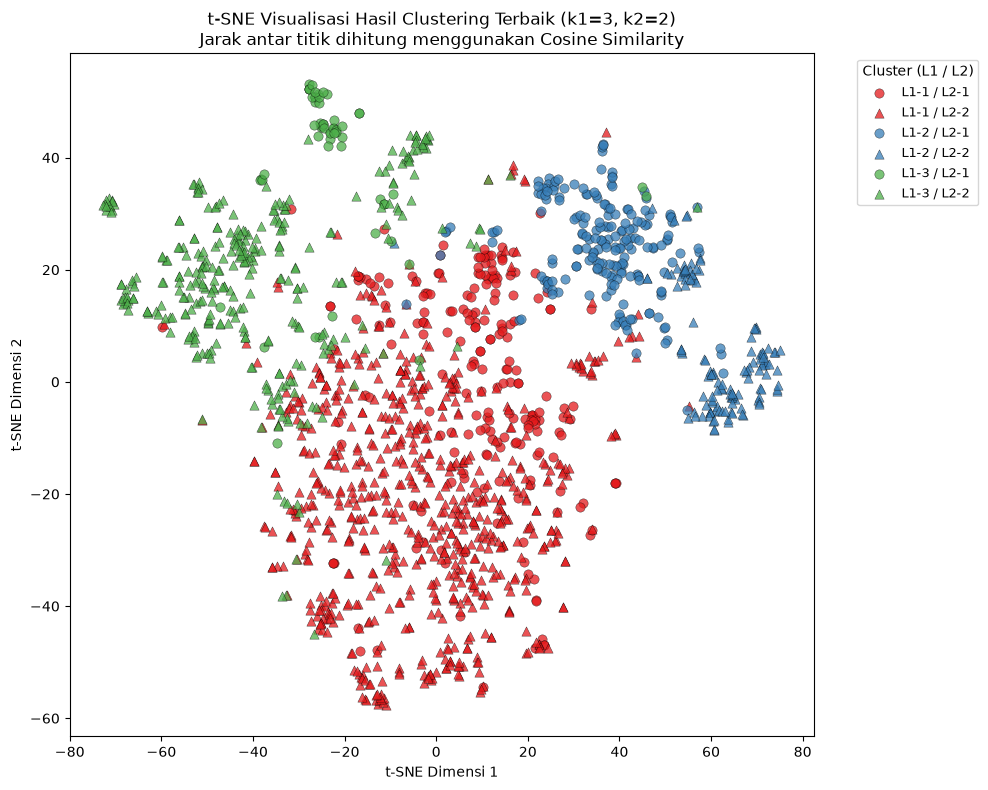

Visualisasi t-SNE disimpan di results/tsne/k3_k2_tsne.png


In [12]:
BEST_K1 = 3
BEST_K2 = 2

# --- Load label Level 1 ---
labels_l1_path = f"results/labels/k{BEST_K1}/labels.csv"
labels_df_l1_best = pd.read_csv(labels_l1_path)

assert len(labels_df_l1_best) == len(df), (
    "Jumlah baris L1 CSV tidak cocok dengan df. "
    "Pastikan df yang dimuat sama dengan saat experiment loop dijalankan (urutan tiket tidak berubah)."
)

cluster_id_l1_arr = labels_df_l1_best['cluster_id'].to_numpy()

# --- Load label Level 2 tiap cluster L1, lalu gabungkan sesuai urutan asli df ---
sub_cluster_id_arr = np.full(len(df), np.nan)

for cid in range(1, BEST_K1 + 1):
    l2_path = f"results/labels/k{BEST_K1}/cluster_{cid}_k{BEST_K2}/labels.csv"
    labels_df_l2 = pd.read_csv(l2_path)

    # Baris L2 CSV mengikuti urutan np.where(cluster_id_l1_arr == cid)[0] (ascending)
    # sesuai cara cluster_indices dibentuk pada experiment loop
    original_idx = np.where(cluster_id_l1_arr == cid)[0]

    assert len(original_idx) == len(labels_df_l2), (
        f"Jumlah baris L2 CSV untuk cluster L1={cid} tidak cocok dengan jumlah anggota cluster tersebut di L1 CSV."
    )

    sub_cluster_id_arr[original_idx] = labels_df_l2['sub_cluster_id'].to_numpy()

assert not np.isnan(sub_cluster_id_arr).any(), "Ada tiket yang tidak mendapat sub_cluster_id (L2)."

# --- t-SNE, jarak dihitung dengan cosine similarity ---
perplexity = min(30, max(5, len(df) // 100))

tsne = TSNE(
    n_components=2,
    metric='cosine',
    perplexity=perplexity,
    init='pca',
    random_state=42
)
X_tsne = tsne.fit_transform(X_embeddings)

# --- Plot ---
markers = ['o', '^', 's', 'D', 'P', 'X']
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#ff7f00', '#984ea3', '#a65628']

fig, ax = plt.subplots(figsize=(10, 8))

for cid in range(1, BEST_K1 + 1):
    for sub_id in range(1, BEST_K2 + 1):
        mask = (cluster_id_l1_arr == cid) & (sub_cluster_id_arr == sub_id)
        ax.scatter(
            X_tsne[mask, 0], X_tsne[mask, 1],
            c=[colors[cid - 1]],
            marker=markers[(sub_id - 1) % len(markers)],
            label=f"L1-{cid} / L2-{sub_id}",
            alpha=0.75,
            s=45,
            edgecolors='k',
            linewidths=0.3
        )

ax.set_title(
    f"t-SNE Visualisasi Hasil Clustering Terbaik (k1={BEST_K1}, k2={BEST_K2})\n"
    "Jarak antar titik dihitung menggunakan Cosine Similarity"
)
ax.set_xlabel("t-SNE Dimensi 1")
ax.set_ylabel("t-SNE Dimensi 2")
ax.legend(title="Cluster (L1 / L2)", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

plt.tight_layout()

save_path = f"results/tsne/k{BEST_K1}_k{BEST_K2}_tsne.png"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, bbox_inches='tight', dpi=150)
plt.show()

print(f"Visualisasi t-SNE disimpan di {save_path}")

## Extraksi Centroid dan 10 Data tiket representatif

Bagian akhir notebook mengambil centroid serta tiket yang paling dekat dan paling jauh dari centroid untuk membantu interpretasi hasil cluster.

In [13]:
import json

# --- Centroid Level 1 (k1 = BEST_K1), didapat langsung dari algoritma spherical k-means faiss ---
# run_skm() memakai faiss.Kmeans(..., spherical=True) dengan seed default (deterministik),
# sehingga hasil re-run pada k1 = BEST_K1 akan konsisten dengan skenario terbaik pada experiment loop.
centroids_l1_arr, labels_l1_arr = run_skm(embedding_dimension, BEST_K1, X_embeddings)

# --- Sanity check: bandingkan label hasil re-run dengan label tersimpan (results/labels/...) ---
match_ratio_l1 = np.mean((labels_l1_arr + 1) == cluster_id_l1_arr)
print(f"Kecocokan label L1 hasil re-run faiss vs label tersimpan: {match_ratio_l1 * 100:.2f}%")

centroids_l1_best = {cid: centroids_l1_arr[cid - 1] for cid in range(1, BEST_K1 + 1)}

# --- Centroid Level 2 (k2 = BEST_K2), dihitung ulang per cluster L1 memakai anggota hasil re-run L1 ---
centroids_l2_best = {}
labels_l2_full = {}  # sub_cluster_id (1-indexed) per cluster L1, mengikuti urutan cluster_indices

for cid in range(1, BEST_K1 + 1):
    cluster_indices = np.where(labels_l1_arr == (cid - 1))[0]
    cluster_embeddings = X_embeddings[cluster_indices]

    centroids_l2_arr, labels_l2_arr = run_skm(embedding_dimension, BEST_K2, cluster_embeddings)

    for sub_id in range(1, BEST_K2 + 1):
        centroids_l2_best[(cid, sub_id)] = centroids_l2_arr[sub_id - 1]

    labels_l2_full[cid] = (cluster_indices, labels_l2_arr + 1)

print(f"Berhasil mengekstrak {len(centroids_l1_best)} centroid L1 dan {len(centroids_l2_best)} centroid L2 "
      f"langsung dari algoritma spherical k-means faiss (k1={BEST_K1}, k2={BEST_K2}).")

# --- Simpan nilai centroid ke CSV (header: level, cluster_id, sub_cluster_id, vector) ---
centroid_rows = []
for cid, vec in centroids_l1_best.items():
    centroid_rows.append({
        "level": "L1",
        "cluster_id": cid,
        "sub_cluster_id": None,
        "vector": json.dumps(vec.tolist())
    })

for (cid, sub_id), vec in centroids_l2_best.items():
    centroid_rows.append({
        "level": "L2",
        "cluster_id": cid,
        "sub_cluster_id": sub_id,
        "vector": json.dumps(vec.tolist())
    })

centroids_df = pd.DataFrame(centroid_rows)

centroid_dir = f"results/centroids/k{BEST_K1}_k{BEST_K2}"
os.makedirs(centroid_dir, exist_ok=True)
centroids_path = f"{centroid_dir}/centroids.csv"
centroids_df.to_csv(centroids_path, index=False, encoding="utf-8", quoting=csv.QUOTE_ALL)

print(f"Nilai centroid disimpan di {centroids_path}")
centroids_df.head()

Kecocokan label L1 hasil re-run faiss vs label tersimpan: 100.00%
Berhasil mengekstrak 3 centroid L1 dan 6 centroid L2 langsung dari algoritma spherical k-means faiss (k1=3, k2=2).
Nilai centroid disimpan di results/centroids/k3_k2/centroids.csv


,level,cluster_id,sub_cluster_id,vector
0,L1,1,NaN,"[0.013221273198723793, -0.0041833422146737576,..."
1,L1,2,NaN,"[-0.0004453603469301015, -0.049601659178733826..."
2,L1,3,NaN,"[-0.01873597875237465, -0.048943985253572464, ..."
3,L2,1,1.0,"[-0.025927331298589706, -0.025576254352927208,..."
4,L2,1,2.0,"[0.02469339780509472, -0.0009706767741590738, ..."


In [14]:
def get_nearest_farthest(embeddings, indices, raw_tickets, centroid, top_n=5):
    """
    Menghitung cosine similarity tiap tiket anggota cluster terhadap centroid-nya.
    Karena embeddings & centroid sudah dinormalisasi (unit vector), dot product == cosine similarity.
    cosine_distance dihitung sebagai (1 - cosine_similarity).
    Mengembalikan top_n tiket dengan similarity tertinggi (terdekat) dan terendah (terjauh).
    """
    sims = embeddings @ centroid
    order = np.argsort(sims)

    farthest_order = order[:top_n]          # similarity terendah -> distance terbesar
    nearest_order = order[::-1][:top_n]     # similarity tertinggi -> distance terkecil

    nearest = [(raw_tickets[indices[i]], float(sims[i])) for i in nearest_order]
    farthest = [(raw_tickets[indices[i]], float(sims[i])) for i in farthest_order]
    return nearest, farthest

raw_tickets_arr = df['RAW TICKET'].to_numpy()

nearest_rows = []
farthest_rows = []

# --- Level 1 ---
for cid in range(1, BEST_K1 + 1):
    indices_l1 = np.where(labels_l1_arr == (cid - 1))[0]

    nearest, farthest = get_nearest_farthest(
        X_embeddings[indices_l1], indices_l1, raw_tickets_arr, centroids_l1_best[cid], top_n=5
    )

    for rank, (ticket, sim) in enumerate(nearest, start=1):
        nearest_rows.append({
            "level": "L1", "cluster_id": cid, "sub_cluster_id": None,
            "rank": rank, "ticket": ticket,
            "cosine_similarity": f"{sim:.4f}", "cosine_distance": f"{1 - sim:.4f}"
        })
    for rank, (ticket, sim) in enumerate(farthest, start=1):
        farthest_rows.append({
            "level": "L1", "cluster_id": cid, "sub_cluster_id": None,
            "rank": rank, "ticket": ticket,
            "cosine_similarity": f"{sim:.4f}", "cosine_distance": f"{1 - sim:.4f}"
        })

# --- Level 2 ---
for cid in range(1, BEST_K1 + 1):
    cluster_indices, sub_labels_1idx = labels_l2_full[cid]

    for sub_id in range(1, BEST_K2 + 1):
        mask_l2 = (sub_labels_1idx == sub_id)
        indices_l2 = cluster_indices[mask_l2]

        nearest, farthest = get_nearest_farthest(
            X_embeddings[indices_l2], indices_l2, raw_tickets_arr, centroids_l2_best[(cid, sub_id)], top_n=5
        )

        for rank, (ticket, sim) in enumerate(nearest, start=1):
            nearest_rows.append({
                "level": "L2", "cluster_id": cid, "sub_cluster_id": sub_id,
                "rank": rank, "ticket": ticket,
                "cosine_similarity": f"{sim:.4f}", "cosine_distance": f"{1 - sim:.4f}"
            })
        for rank, (ticket, sim) in enumerate(farthest, start=1):
            farthest_rows.append({
                "level": "L2", "cluster_id": cid, "sub_cluster_id": sub_id,
                "rank": rank, "ticket": ticket,
                "cosine_similarity": f"{sim:.4f}", "cosine_distance": f"{1 - sim:.4f}"
            })

print(f"Ditemukan {len(nearest_rows)} baris tiket terdekat dan {len(farthest_rows)} baris tiket terjauh "
      f"dari total {len(centroids_l1_best) + len(centroids_l2_best)} centroid.")

Ditemukan 45 baris tiket terdekat dan 45 baris tiket terjauh dari total 9 centroid.


In [15]:
nearest_df = pd.DataFrame(nearest_rows)
farthest_df = pd.DataFrame(farthest_rows)

nearest_path = f"{centroid_dir}/nearest_tickets.csv"
farthest_path = f"{centroid_dir}/farthest_tickets.csv"

nearest_df.to_csv(nearest_path, index=False, encoding="utf-8", quoting=csv.QUOTE_ALL)
farthest_df.to_csv(farthest_path, index=False, encoding="utf-8", quoting=csv.QUOTE_ALL)

print(f"Tiket terdekat (5 per centroid) disimpan di {nearest_path}")
print(f"Tiket terjauh (5 per centroid) disimpan di {farthest_path}")

nearest_df.head(10)

Tiket terdekat (5 per centroid) disimpan di results/centroids/k3_k2/nearest_tickets.csv
Tiket terjauh (5 per centroid) disimpan di results/centroids/k3_k2/farthest_tickets.csv


,level,cluster_id,sub_cluster_id,rank,ticket,cosine_similarity,cosine_distance
0,L1,1,NaN,1,Klien: BTN\nIsu: Media Online Tidak Bisa Masuk...,0.8994,0.1006
1,L1,1,NaN,2,Isu : Berita ada di database tidak bisa masuk ...,0.8944,0.1056
2,L1,1,NaN,3,klien: Pelindo\nisu: gagal input siputra\n\nse...,0.8909,0.1091
3,L1,1,NaN,4,Klien: Askrindo\nKendala: NNA di Tele tidak mu...,0.8904,0.1096
4,L1,1,NaN,5,Klien : Kemenkum\nIsu : Data Youtube tidak mas...,0.8838,0.1162
5,L1,2,NaN,1,Selamat siang mas @Dhanysybn dan tim punteun r...,0.9390,0.0610
6,L1,2,NaN,2,Selamat malam mas @Dhanysybn dan tim info reco...,0.9354,0.0646
7,L1,2,NaN,3,"Selamat pagi mas @IndraVidho @Dhanysybn , info...",0.9286,0.0714
8,L1,2,NaN,4,"Selamat sore mas @Dhanysybn dan tim, punteun i...",0.9225,0.0775
9,L1,2,NaN,5,Selamat pagi mas @IndraVidho @Dhanysybn inform...,0.9204,0.0796
